<a href="https://colab.research.google.com/github/JuanJGalindo/SpinesAI_Direct/blob/main/SpinPrecession_HNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Non-Canonical System Implementation - Example of Spin Precession along X-Axis**

This framework defines the benchmarks for two neural architectures designed to learn the dynamics of a classical spin system. The system under study is the Larmor precession of a single magnetic moment in a constant magnetic field, a fundamental problem in magnetism and geometric mechanics.

---

##**1. Physical System: Classical Spin Precession**
We consider a single spin vector $\mathbf{S} \in \mathbb{R}^3$ subject to an external magnetic field $\mathbf{B}$. The spin is a unit vector, constrained to the surface of the 2-sphere $S^2$.

###**1.1 The Hamiltonian**
The energy of the system is given by the Zeeman interaction:

$$\mathcal{H}(\mathbf{S}) = - \mathbf{B} \cdot \mathbf{S}$$

The system seeks to rotate around the axis of the magnetic field $\mathbf{B}$ while preserving its energy and its magnitude.

###**1.2 The Lie-Poisson Structure**
Unlike standard particle mechanics, spin variables do not satisfy canonical commutation relations. Instead, they follow the $\mathfrak{so}(3)$ algebra, defined by the Lie-Poisson bracket:$$\{S_a, S_b\} = \epsilon_{abc} S_c$$where $\epsilon_{abc}$ is the Levi-Civita symbol. This leads to the equations of motion:

$$\dot{\mathbf{S}} = \{\mathbf{S}, \mathcal{H}\} = \mathbf{S} \times \left( \frac{\partial \mathcal{H}}{\partial \mathbf{S}} \right) = \mathbf{S} \times (-\mathbf{B}) = \mathbf{S} \times \mathbf{B}$$

This cross-product structure ensures that $\dot{\mathbf{S}}$ is always perpendicular to $\mathbf{S}$, meaning the motion is confined to the sphere $S^2$.

---

##**2. Geometry of the Phase Space**
The $S^2$ SphereThe phase space of a single spin is the sphere $S^2 = \{ \mathbf{S} \in \mathbb{R}^3 : \|\mathbf{S}\|^2 = 1 \}$.Symplectic Structure: $S^2$ is a symplectic manifold, but it possesses no global canonical coordinates $(\mathbf{q}, \mathbf{p})$.Casimir Invariant: The norm $C = S_x^2 + S_y^2 + S_z^2$ is a Casimir function of the Poisson algebra. Its value is constant ($C=1$) for any Hamiltonian flow.

##**3. Neural Network Architectures**

###**3.1 Canonical HNN (Greydanus et al.)**
The standard Hamiltonian Neural Network (HNN) assumes the existence of canonical coordinates $\mathbf{z} = (\mathbf{q}, \mathbf{p})$ and a constant symplectic matrix $\mathbb{J}$:

$$\dot{\mathbf{z}} = \mathbb{J} \nabla \mathcal{H}_{\theta}(\mathbf{z}), \quad \mathbb{J} = \begin{pmatrix} 0 & I \\ -I & 0 \end{pmatrix}$$

Because $S^2$ is not $\mathbb{R}^{2n}$, we must map the spin to an artificial canonical space (e.g., azimuthal angle and longitudinal momentum).

###**3.2 Poisson-aware HNN (PoissonHNN)**
To respect the non-canonical geometry, the PoissonHNN incorporates the state-dependent Poisson tensor $\mathbb{B}(\mathbf{S})$ directly into the architecture:

$$\dot{\mathbf{S}} = \mathbb{B}(\mathbf{S}) \nabla \mathcal{H}_{\theta}(\mathbf{S}) = \mathbf{S} \times \nabla \mathcal{H}_{\theta}(\mathbf{S})$$

This hard-codes the Lie-Poisson structure, ensuring that the predicted velocity $\dot{\mathbf{S}}$ is exactly tangent to the sphere.

---

##**4. Coordinate Mappings (Darboux Coordinates)**

To facilitate the Canonical HNN, we use the following mappings between the spin vector $\mathbf{S}$ and canonical coordinates $(q, p)$:

**Forward Mapping ($S \to q, p$):**

$$p = S_z$$$$q = \text{atan2}(S_y, S_x)$$

where $p$ represents the conjugate momentum (projection on the $Z$-axis) and $q$ represents the generalized position (azimuthal angle).

**Inverse Mapping ($q, p \to S$):**

$$S_x = \sqrt{1 - p^2} \cos(q)$$$$S_y = \sqrt{1 - p^2} \sin(q)$$$$S_z = p$$

---

##**5. Numerical Integration: The RK45 vs. Geometric Methods**

Both models are integrated using the Runge-Kutta 45 (RK45) algorithm, an adaptive explicit solver.

###**5.1 The Manifold Drift Problem**
While the PoissonHNN is mathematically guaranteed to stay on the sphere in continuous time, the discrete steps of the RK45 solver introduce numerical drift.

RK45 moves along the tangent plane of the sphere, because the sphere is curved, a straight-line step moves the point slightly "off" the manifold. In $\mathbb{R}^3$, this results in a shrinking norm $\|\mathbf{S}\|$, leading to artificial energy dissipation. In contrast, the CanonicalHNN appears to conserve the norm better because the inverse mapping (using $\sin$ and $\cos$) analytically forces the vector back onto the sphere, effectively hiding the integrator's error.

To resolve this fairly, Geometric Integration methods must be used to enforce structural constraints on the analytical and predicted trajectories.

##**6. Evaluation Metrics**

The implementation and evaluation of a Hamiltonian Neural Network (HNN) for spin dynamics necessitate a rigorous mathematical framework to distinguish between structural learning and numerical artifacts. When dealing with systems on the 2-sphere ($S^2$), the traditional Euclidean metrics often fail to capture the geometric nuances of the motion. Consequently, a multifaceted suite of metrics is required to assess whether the model has truly learned the underlying physics or is simply approximating a trajectory through curve-fitting.

-   **Phase Space 3D Map:** Serves as the primary qualitative heuristic for assessing topological integrity. By visualizing the predicted trajectory in $\mathbb{R}^3$, one can immediately identify whether the model respects the spherical constraint. A successful model will produce a perfectly circular orbit that remains on the surface of the sphere, whereas a model suffering from structural or numerical instability will exhibit spiraling behavior, either collapsing toward the origin or expanding outward. This visualization is essential for a high-level understanding of the system's global stability.

-   **Loss Progression:** Provides a quantitative measure of the optimization process during the training phase. It typically represents the Mean Squared Error between the predicted time derivatives and the ground truth derivatives across the training dataset. While a low loss indicates that the network has successfully approximated the local vector field, it does not inherently guarantee long-term stability or conservation of physical quantities. It is a metric of local fitting rather than global geometric consistency.

-   **Energy Error and Relative Energy Error:** Focused on the thermodynamic consistency of the model. The Energy Error measures the absolute difference between the learned Hamiltonian and the analytical value, which should ideally remain constant. However, because absolute values are scale-dependent, the Relative Energy Error is a more informative heuristic. It normalizes the drift by the initial energy, allowing for a standardized comparison across different systems. In a truly Hamiltonian system, these errors should oscillate within a tight bound rather than grow monotonically, as monotonic growth indicates unphysical dissipation or gain in the system’s energy.

-   **Spin Norm Conservation Error and Casimir Error:** Addresses the geometric constraints of the Lie-Poisson manifold. The Spin Norm Error tracks the deviation of the vector's length from unity, which is a fundamental requirement for any spin system. The Casimir Error specifically measures the drift of the quadratic invariant $\|\mathbf{S}\|^2 = 1$ associated with the $\mathfrak{so}(3)$ algebra. While these two metrics are mathematically related, the Casimir Error is the formal representation of structural preservation in Poisson mechanics. A failure in these metrics, especially in the PoissonHNN integrated with a non-geometric solver like RK45, often highlights the limitations of the numerical integrator rather than the neural network's architecture.

-   **Cosine Similarity:** Serves as a critical heuristic for assessing phase accuracy. By calculating the angular alignment between the predicted spin vector and the analytical ground truth, this metric effectively ignores the magnitude of the vectors and focuses solely on their direction in phase space. This is particularly useful because it decouples the "shrinkage" caused by numerical integration from the "timing" of the learned dynamics. A high cosine similarity indicates that the model has correctly captured the frequency and axis of the precession, even if the vector's norm has degraded due to the integrator's failure to respect the manifold curvature. A degraded learned dynamics might cause an oscillating behavior of the metric over time, as the frequency of the oscillation increases, poorer learned dynamics will appear in the system.

In [ ]:
!pip install hnn

  Using cached hnn-0.0.3.5.tar.gz (33 kB)
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of hnn to determine which version is compatible with other requirements. This could take a while.
  Using cached hnn-0.0.3.4.tar.gz (33 kB)
  Preparing metadata (setup.py) ... done
  Using cached hnn-0.0.3.3.tar.gz (33 kB)
  Preparing metadata (setup.py) ... done
  Using cached hnn-0.0.3.2.tar.gz (32 kB)
  Preparing metadata (setup.py) ... done
  Using cached hnn-0.0.3.1.tar.gz (32 kB)
  Preparing metadata (setup.py) ... done
ERROR: Cannot install hnn==0.0.3.1, hnn==0.0.3.2, hnn==0.0.3.3, hnn==0.0.3.4 and hnn==0.0.3.5 because these package versions have conflicting dependencies.

The conflict is caused by:
    hnn 0.0.3.5 depends on torch==1.11.0
    hnn 0.0.3.4 depends on torch==1.11.0
    hnn 0.0.3.3 depends on torch==1.11.0
    hnn 0.0.3.2 depends on torch==1.11.0
    hnn 0.0.3.1 depends on torch==1.11.0

To fix this you could try to:
1. loosen the range of pa

**Imports and Seed Parametrization**

In [ ]:
import os
import sys
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Greydanus HNN Import
try:
    from hnn import HNN
except ImportError:
    print("Greydanus' HNN couldn't be imported")

Greydanus' HNN couldn't be imported


**HNN, PoissonHNN and Baseline MLP Implementations**

In [ ]:
class HNN(nn.Module):
    """
    Minimal canonical Hamiltonian Neural Network mimicking Greydanus (2019).
    Assumes input is canonically conjugate pairs z = (q, p).
    Computes dot(z) = J \nabla H.
    """

    def __init__(self, differentiable_model):
        super(HNN, self).__init__()
        self.baseline = differentiable_model

    def forward(self, x):
        # Split into coordinates (q) and momenta (p)
        q, p = torch.split(x, x.shape[-1] // 2, dim=-1)
        q.requires_grad_(True)
        p.requires_grad_(True)

        # Recombine to pass into the energy model
        z = torch.cat([q, p], dim=-1)
        H = self.baseline(z)

        # Compute canonical gradients
        dH_dq = torch.autograd.grad(H.sum(), q, create_graph=True)[0]
        dH_dp = torch.autograd.grad(H.sum(), p, create_graph=True)[0]

        # Apply symplectic matrix J: dq/dt = dH/dp, dp/dt = -dH/dq
        return torch.cat([dH_dp, -dH_dq], dim=-1)

In [ ]:
class PoissonHNN(nn.Module):
    """
    Modified Hamiltonian Neural Network for Lie-Poisson systems.
    Computes dot(S) = B(S) \nabla H = S x \nabla H.
        Preserves structural invariants like |S| = 1 automatically.
    """

    def __init__(self, differentiable_model):
        super(PoissonHNN, self).__init__()
        self.baseline = differentiable_model

    def forward(self, S):
        S = S.clone().requires_grad_(True)

        # Predict scalar Energy H
        H = self.baseline(S)

        # Compute gradient \nabla H w.r.t spin vector S
        dH_dS = torch.autograd.grad(H.sum(), S, create_graph=True)[0]

        # Lie-Poisson dynamics: dot(S) = S x \nabla H
        S_dot = torch.linalg.cross(S, dH_dS, dim=-1)

        return S_dot

In [ ]:
class MLP(nn.Module):
    """Simple 2-layer Multi-Layer Perceptron to predict Energy H."""

    def __init__(self, input_dim, hidden_dim=64):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False)
        )

    def forward(self, x):
        return self.net(x)

**Analytical Solution Implementation and Data Generation**

Classical Spin Precession with B-field along the X-axis
$$H = -B \cdot S = -B_x * S_x$$
$$\dot{S} = S \times B$$

In [ ]:
B_FIELD = np.array([1.0, 0.0, 0.0])

# Analytical Solution
def analytical_spin_derivative(t, S):
    """Exact dynamics for dataset generation."""

    return np.cross(S, B_FIELD)

# From Original Spin-like to Canonical
def S_to_qp(S):
    """
    Map Spin S in R^3 to canonical coordinates (q, p).
    p = S_z
    q = arctan2(S_y, S_x)
    """

    S = np.atleast_2d(S)
    p = S[:, 2]
    q = np.arctan2(S[:, 1], S[:, 0])
    return np.stack([q, p], axis=-1)

# From Canonical to Original Spin-like
def qp_to_S(qp):
    """
    Map canonical (q, p) back to Spin S.
    S_z = p
    S_x = sqrt(1 - p^2) * cos(q)
    S_y = sqrt(1 - p^2) * sin(q)
    """

    qp = np.atleast_2d(qp)
    q = qp[:, 0]
    p = qp[:, 1]

    sin_theta = np.sqrt(1 - p**2)

    S_x = sin_theta * np.cos(q)
    S_y = sin_theta * np.sin(q)
    S_z = p
    return np.stack([S_x, S_y, S_z], axis=-1)

# Numerical Data Generation
def get_training_data(num_samples=500, dt=0.05):
    """Generate training trajectories using the analytical ODE."""

    t_span = (0, dt * num_samples)
    t_eval = np.linspace(t_span[0], t_span[1], num_samples)

    # Random Initial Condition
    S0 = np.random.rand(3)
    S0 = S0 / np.linalg.norm(S0)

    # Solve exact ODE
    sol = solve_ivp(analytical_spin_derivative, t_span, S0, t_eval=t_eval, rtol=1e-9, atol=1e-9)
    S_data = sol.y.T  # (N, 3)
    S_dot_data = np.array([analytical_spin_derivative(0, s) for s in S_data])

    # Convert to canonical coordinates
    qp_data = S_to_qp(S_data)

    # Numerical derivatives for qp
    qp_dot_data = np.gradient(qp_data, t_eval, axis=0)

    return t_eval, S_data, S_dot_data, qp_data, qp_dot_data


**Model Training**

In [ ]:
def train_model(model, inputs, targets, epochs=2000, lr=1e-3):
    """Standard L2 training loop for derivatives."""

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    inputs_t = torch.tensor(inputs, dtype=torch.float32)
    targets_t = torch.tensor(targets, dtype=torch.float32)

    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(inputs_t)
        loss = loss_fn(preds, targets_t)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if epoch % 250 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

    return loss_history

**Model Integration and Evaluation**

In [ ]:
def rollout_canonical(model, qp0, t_eval):
    """Integrate learned Canonical HNN over time."""

    def odefunc(t, qp):
        qp_t = torch.tensor(qp, dtype=torch.float32).unsqueeze(0)
        # HNN needs grad to compute dH/dq and dH/dp internally
        with torch.enable_grad():
            qp_dot = model(qp_t).squeeze().detach().numpy()
        return qp_dot

    sol = solve_ivp(odefunc, (t_eval[0], t_eval[-1]), qp0, t_eval=t_eval)
    qp_pred = sol.y.T
    return qp_to_S(qp_pred)


def rollout_poisson(model, S0, t_eval):
    """Integrate learned Poisson HNN over time."""

    def odefunc(t, S):
        S_t = torch.tensor(S, dtype=torch.float32).unsqueeze(0)
        # PoissonHNN uses gradients internally for dH/dS
        with torch.enable_grad():
            S_dot = model(S_t).squeeze().detach().numpy()
        return S_dot

    sol = solve_ivp(odefunc, (t_eval[0], t_eval[-1]), S0, t_eval=t_eval)
    return sol.y.T

def compute_energy(S):
    return -np.sum(S * B_FIELD, axis=1)

def compute_norm(S):
    return np.linalg.norm(S, axis=1)

def casimir_error(S):
    return np.abs(np.linalg.norm(S, axis=1) - 1.0)

def relative_energy_error(E_pred, E_true):
    return np.abs(E_pred - E_true) / np.abs(E_true[0])

def cosine_similarity_metric(S_pred, S_true):
    dot_product = np.sum(S_pred * S_true, axis=1)
    norm_pred = np.linalg.norm(S_pred, axis=1)
    norm_true = np.linalg.norm(S_true, axis=1)
    return dot_product / (norm_pred * norm_true)

In [ ]:
import unittest

def test_rollouts():
    # Setup minimal models and data for testing
    t_test = np.linspace(0, 0.1, 5)
    s0_test = np.array([0.0, 0.0, 1.0])
    qp0_test = S_to_qp(s0_test).flatten()

    # Initialize models
    mlp_c = MLP(input_dim=2, hidden_dim=16)
    hnn_c = HNN(mlp_c)
    mlp_p = MLP(input_dim=3, hidden_dim=16)
    phnn = PoissonHNN(mlp_p)

    print("Running Unit Test for Rollout Functions...")

    # Test Canonical Rollout
    try:
        s_canon_out = rollout_canonical(hnn_c, qp0_test, t_test)
        assert s_canon_out.shape == (5, 3), f"Canonical shape mismatch: {s_canon_out.shape}"
        print("rollout_canonical: Passed shape and integration test.")
    except Exception as e:
        print(f"rollout_canonical: Failed with error: {e}")

    # Test Poisson Rollout
    try:
        s_poiss_out = rollout_poisson(phnn, s0_test, t_test)
        assert s_poiss_out.shape == (5, 3), f"Poisson shape mismatch: {s_poiss_out.shape}"
        print("rollout_poisson: Passed shape and integration test.")
    except Exception as e:
        print(f"rollout_poisson: Failed with error: {e}")

test_rollouts()

Running Unit Test for Rollout Functions...
rollout_canonical: Passed shape and integration test.
rollout_poisson: Passed shape and integration test.


**Benchmark Execution - Main**

In [ ]:
if __name__ == "__main__":
    print("Generating dataset...")
    t_eval, S_data, S_dot_data, qp_data, qp_dot_data = get_training_data(num_samples=1000)

    print("\n--- Training Canonical HNN ---")
    mlp_canonical = MLP(input_dim=2, hidden_dim=64)
    model_canonical = HNN(mlp_canonical)
    loss_canonical = train_model(model_canonical, qp_data, qp_dot_data)

    print("\n--- Training Poisson-Aware HNN ---")
    mlp_poisson = MLP(input_dim=3, hidden_dim=64)
    model_poisson = PoissonHNN(mlp_poisson)
    loss_poisson = train_model(model_poisson, S_data, S_dot_data)

    print("\nSimulating Long-Time Dynamics...")
    # Evaluate over a longer time horizon to test stability
    t_long = np.linspace(0, 150, 5000)
    S0 = S_data[0]
    qp0 = qp_data[0]

    # 1. True Analytical Trajectory
    sol_true = solve_ivp(analytical_spin_derivative, (t_long[0], t_long[-1]), S0, t_eval=t_long)
    S_true = sol_true.y.T

    # 2. Canonical HNN Trajectory
    S_canon = rollout_canonical(model_canonical, qp0, t_long)

    # 3. Poisson HNN Trajectory
    S_poiss = rollout_poisson(model_poisson, S0, t_long)

    # Energy Magnitude
    E_true = compute_energy(S_true)
    E_canon = compute_energy(S_canon)
    E_poiss = compute_energy(S_poiss)

    # Spin Norm
    N_true = compute_norm(S_true)
    N_canon = compute_norm(S_canon)
    N_poiss = compute_norm(S_poiss)

    # Casimir Error
    casimir_err_canon = casimir_error(S_canon)
    casimir_err_poiss = casimir_error(S_poiss)

    # Relative Energy Error
    rel_E_err_canon = relative_energy_error(E_canon, E_true)
    rel_E_err_poiss = relative_energy_error(E_poiss, E_true)

    # Cosine Similarity
    cos_sim_canon = cosine_similarity_metric(S_canon, S_true)
    cos_sim_poiss = cosine_similarity_metric(S_poiss, S_true)

Generating dataset...

--- Training Canonical HNN ---
Epoch    0 | Loss: 1.040516
Epoch  250 | Loss: 0.002691
Epoch  500 | Loss: 0.000359
Epoch  750 | Loss: 0.000115
Epoch 1000 | Loss: 0.000064
Epoch 1250 | Loss: 0.000043
Epoch 1500 | Loss: 0.000030
Epoch 1750 | Loss: 0.000021

--- Training Poisson-Aware HNN ---
Epoch    0 | Loss: 0.370593
Epoch  250 | Loss: 0.000014
Epoch  500 | Loss: 0.000003
Epoch  750 | Loss: 0.000002
Epoch 1000 | Loss: 0.000001
Epoch 1250 | Loss: 0.000001
Epoch 1500 | Loss: 0.000000
Epoch 1750 | Loss: 0.000000

Simulating Long-Time Dynamics...


**Plotting**

<>:47: SyntaxWarning: invalid escape sequence '\e'
<>:47: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4760/3240319120.py:47: SyntaxWarning: invalid escape sequence '\e'
  ax4.set_title("Relative Energy Error $\epsilon_H(t)$")
/tmp/ipykernel_4760/3240319120.py:80: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()


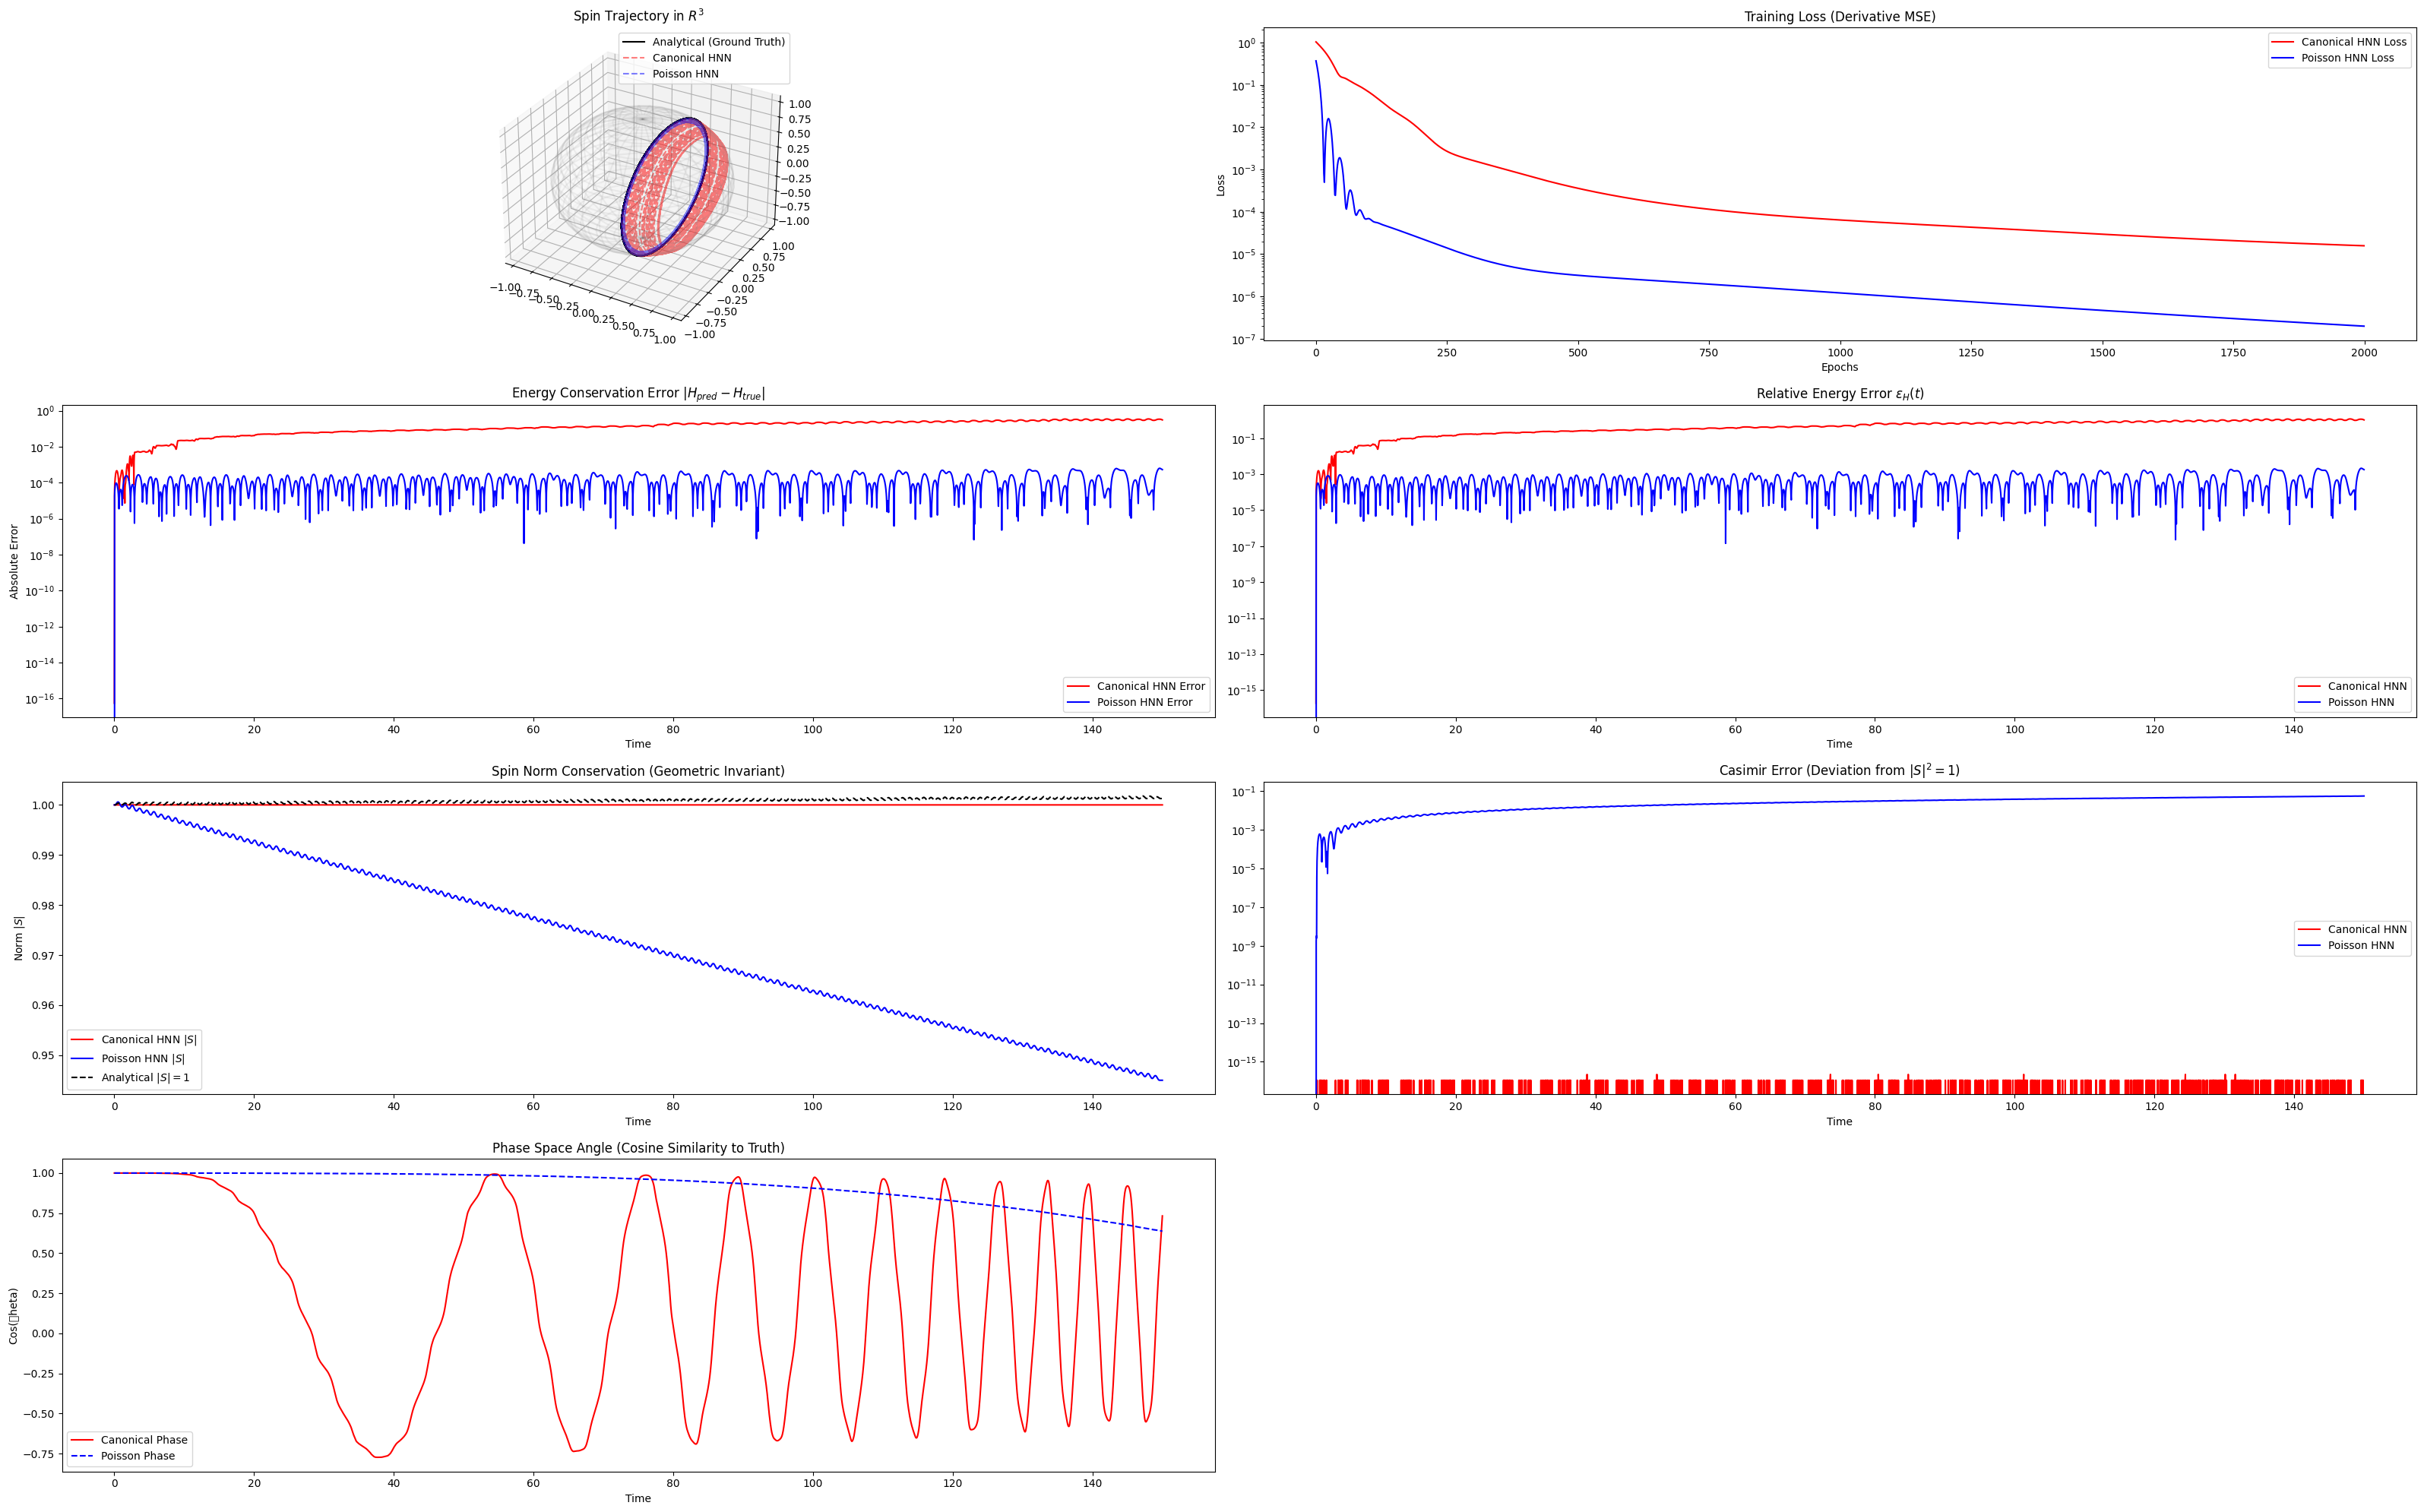

In [ ]:
fig = plt.figure(figsize=(32, 20))

# Plot 1: 3D Phase Space Trajectories
ax1 = fig.add_subplot(4, 2, 1, projection='3d')
ax1.plot(S_true[:, 0], S_true[:, 1], S_true[:, 2], 'k-', label="Analytical (Ground Truth)")
ax1.plot(S_canon[:, 0], S_canon[:, 1], S_canon[:, 2], 'r--', alpha=0.5, label="Canonical HNN")
ax1.plot(S_poiss[:, 0], S_poiss[:, 1], S_poiss[:, 2], 'b--', alpha=0.5, label="Poisson HNN")

# Draw unit sphere for reference
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_sph = np.outer(np.cos(u), np.sin(v))
y_sph = np.outer(np.sin(u), np.sin(v))
z_sph = np.outer(np.ones_like(u), np.cos(v))
ax1.plot_wireframe(x_sph, y_sph, z_sph, color="grey", alpha=0.1)

ax1.set_title("Spin Trajectory in $R^3$")
ax1.set_xlim([-1.1, 1.1])
ax1.set_ylim([-1.1, 1.1])
ax1.set_zlim([-1.1, 1.1])
ax1.legend()

# Plot 2: Training Loss Curves
ax2 = fig.add_subplot(4, 2, 2)
ax2.plot(loss_canonical, 'r-', label="Canonical HNN Loss")
ax2.plot(loss_poisson, 'b-', label="Poisson HNN Loss")
ax2.set_title("Training Loss (Derivative MSE)")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_yscale("log")
ax2.legend()

# Plot 3: Energy Conservation Error
ax3 = fig.add_subplot(4, 2, 3)
ax3.plot(t_long, np.abs(E_canon - E_true), 'r-', label="Canonical HNN Error")
ax3.plot(t_long, np.abs(E_poiss - E_true), 'b-', label="Poisson HNN Error")
ax3.set_title("Energy Conservation Error $|H_{pred} - H_{true}|$")
ax3.set_xlabel("Time")
ax3.set_ylabel("Absolute Error")
ax3.set_yscale("log")
ax3.legend()

# Plot 4: Relative Energy Error
ax4 = fig.add_subplot(4, 2, 4)
ax4.plot(t_long, rel_E_err_canon, 'r-', label="Canonical HNN")
ax4.plot(t_long, rel_E_err_poiss, 'b-', label="Poisson HNN")
ax4.set_title("Relative Energy Error $\epsilon_H(t)$")
ax4.set_xlabel("Time")
ax4.set_yscale("log")
ax4.legend()

# Plot 5: Spin Norm Conservation
ax5 = fig.add_subplot(4, 2, 5)
ax5.plot(t_long, N_canon, 'r-', label="Canonical HNN $|S|$")
ax5.plot(t_long, N_poiss, 'b-', label="Poisson HNN $|S|$")
ax5.plot(t_long, N_true, 'k--', label="Analytical $|S|=1$")
ax5.set_title("Spin Norm Conservation (Geometric Invariant)")
ax5.set_xlabel("Time")
ax5.set_ylabel("Norm $|S|$")
ax5.legend()

# Plot 6: Casimir Error
ax6 = fig.add_subplot(4, 2, 6)
ax6.plot(t_long, casimir_err_canon, 'r-', label="Canonical HNN")
ax6.plot(t_long, casimir_err_poiss, 'b-', label="Poisson HNN")
ax6.set_title("Casimir Error (Deviation from $|S|^2=1$)")
ax6.set_xlabel("Time")
ax6.set_yscale("log")
ax6.legend()

# Plot 7: Cosine Similarity
ax7 = fig.add_subplot(4, 2, 7)
ax7.plot(t_long, cos_sim_canon, 'r-', label="Canonical Phase")
ax7.plot(t_long, cos_sim_poiss, 'b--', label="Poisson Phase")
ax7.set_title("Phase Space Angle (Cosine Similarity to Truth)")
ax7.set_xlabel("Time")
ax7.set_ylabel("Cos(\theta)")
ax7.legend(loc="lower left")

plt.tight_layout()
plt.show()

##**Discussion**

The provided benchmark results offer a definitive comparison between the CanonicalHNN (based on Darboux coordinates) and the PoissonHNN (built on Lie-Poisson gradients). While the Canonical model appears superficially more stable in its geometric invariants, a critical analysis of the dynamical metrics reveals that the PoissonHNN captures the underlying physical reality with far greater precision.

The following points detail the performance trade-offs and structural behaviors observed in the simulation:

- **Phase Accuracy:** The most striking differentiation is found in the Cosine Similarity plot. The CanonicalHNN exhibits high-frequency, large-amplitude oscillations, indicating a severe phase mismatch; the model is precessing at the wrong frequency, causing it to periodically align and misalign with the ground truth. In contrast, the PoissonHNN maintains a cosine similarity near $1.0$ for the majority of the rollout, mismatching appears the moment spin norm conservation starts to break. Overall, this shows that the PoissonHNN has learned a significantly more accurate representation of the system's "internal clock" and rotational velocity, whereas the Canonical model has failed to synchronize its dynamics with the physical frequency of the magnetic field.

- **Energy Conservation:** The Energy Error metrics show that the PoissonHNN is orders of magnitude more accurate than its canonical counterpart. The PoissonHNN error remains low and exhibits a bounded, oscillatory nature, which is a hallmark of successful Hamiltonian learning. The CanonicalHNN, however, shows a steadily increasing energy error that is orders of magnitude higher. This suggests that the canonical mapping $(q, p)$, while mathematically valid, introduces complexities or singularities that the network struggles to resolve, leading to a poorer approximation of the scalar energy function $\mathcal{H}$.

- **Spin Norm Conservation:** There is a notable paradox in the Spin Norm Conservation and Casimir Error plots. The CanonicalHNN shows near-perfect conservation (Very shallow slope increasing behavior), but this is an artifact of the coordinate transformation rather than learned physics; the mapping from $(q, p)$ to $S$ analytically forces the vector onto the sphere. The PoissonHNN shows a linear decay in the spin norm, which is a classic symptom of using a non-geometric integrator (RK45) in an embedded 3D space. Because the PoissonHNN operates in $\mathbb{R}^3$, the numerical solver "falls off" the curved manifold at every time step.

- **Phase Space Stability:** Both models appear to follow a circular path, but the "thickness" of the lines in the plots suggests different failure modes. The CanonicalHNN stays on the correct spherical shell but drifts in time (phase error), which appears as a rotation of the described trajectory ring; while the PoissonHNN stays synchronized in time but slowly spirals inward (norm error).


##**Conclusions**:
The benchmark highlights that the PoissonHNN is the superior physical model, as evidenced by its exceptional energy conservation and phase accuracy. Its possible that its major weakness, which is the drift in the spin norm, is a numerical artifact of the integration scheme rather than a failure of the neural network. Conversely, the CanonicalHNN provides a false sense of security; it preserves the geometry through coordinate constraints but fails to accurately learn the actual dynamics of the precession. A further geometric integrator implementation must be done to ensure with greater confidence the conclusions above.